<a href="https://colab.research.google.com/github/SenaliBandara/regression_projects/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn import datasets

In [ ]:
from sklearn.datasets import fetch_california_housing
housing=fetch_california_housing()
housing_df=pd.DataFrame(data=housing.data,columns=housing.feature_names)
housing_df['HousePrice']=housing.target
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
housing_df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HousePrice,0


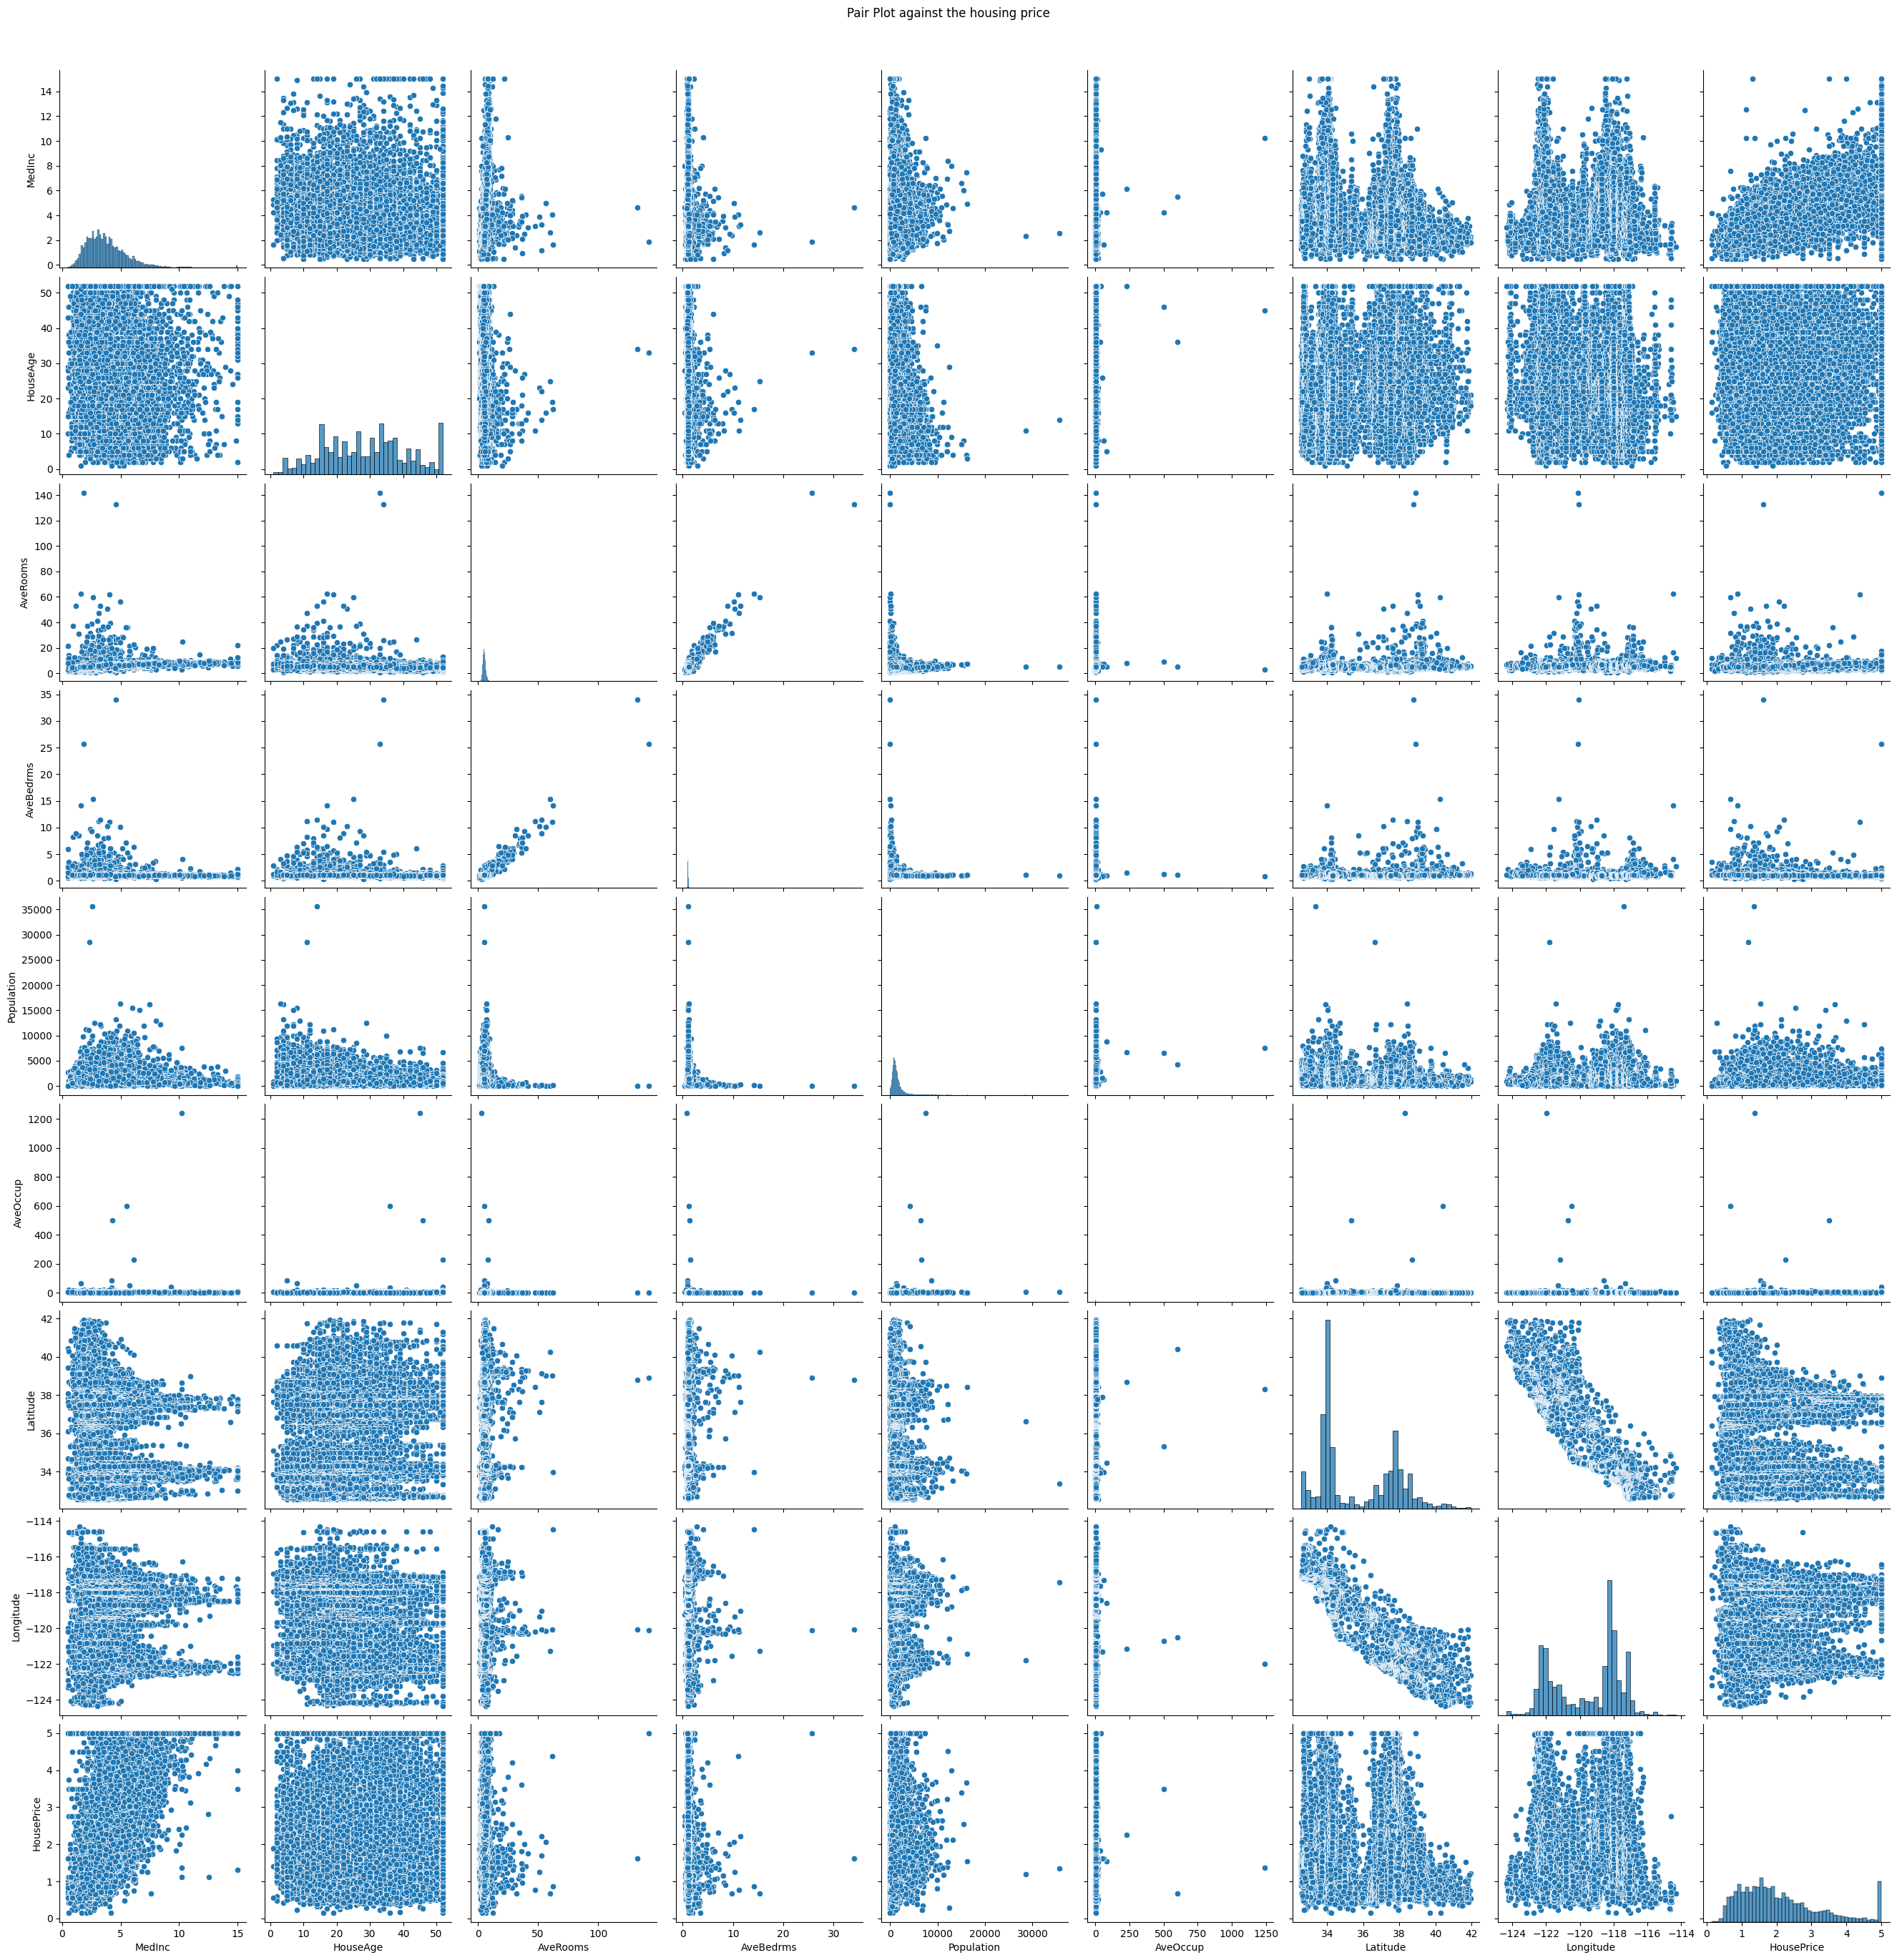

In [ ]:
sns.pairplot(housing_df,height=3)
plt.suptitle('Pair Plot against the housing price',y=1.02)
plt.show()

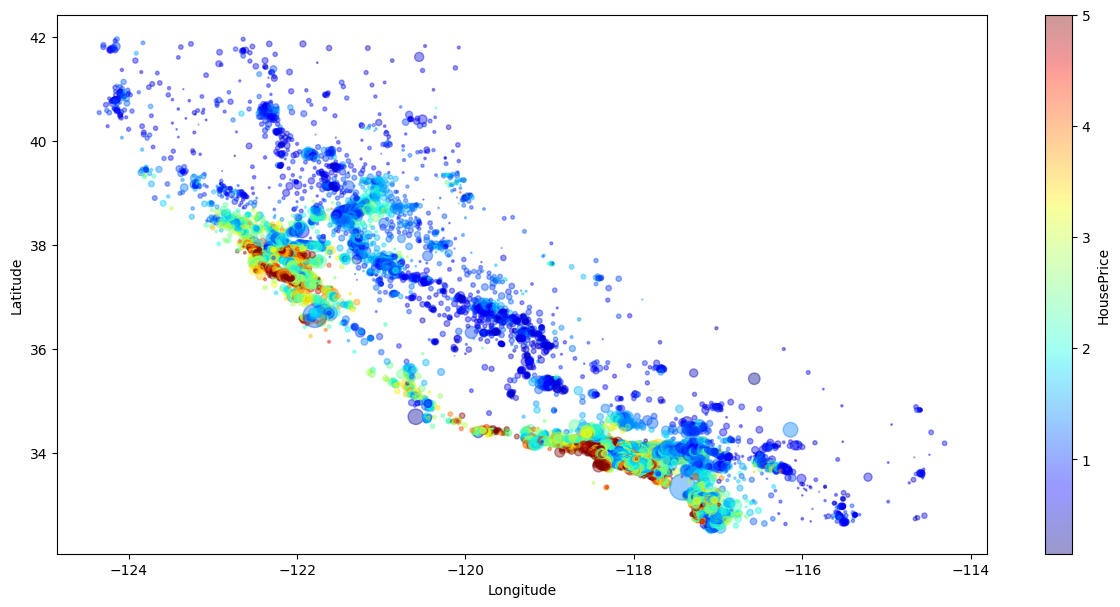

In [ ]:
housing_df.plot(
    kind='scatter',
    x='Longitude',
    y='Latitude',
    alpha=0.4,
    c='HousePrice',
    s=housing_df['Population']/100,
    cmap='jet',
    colorbar=True,
    figsize=(15,7)
)
plt.show()

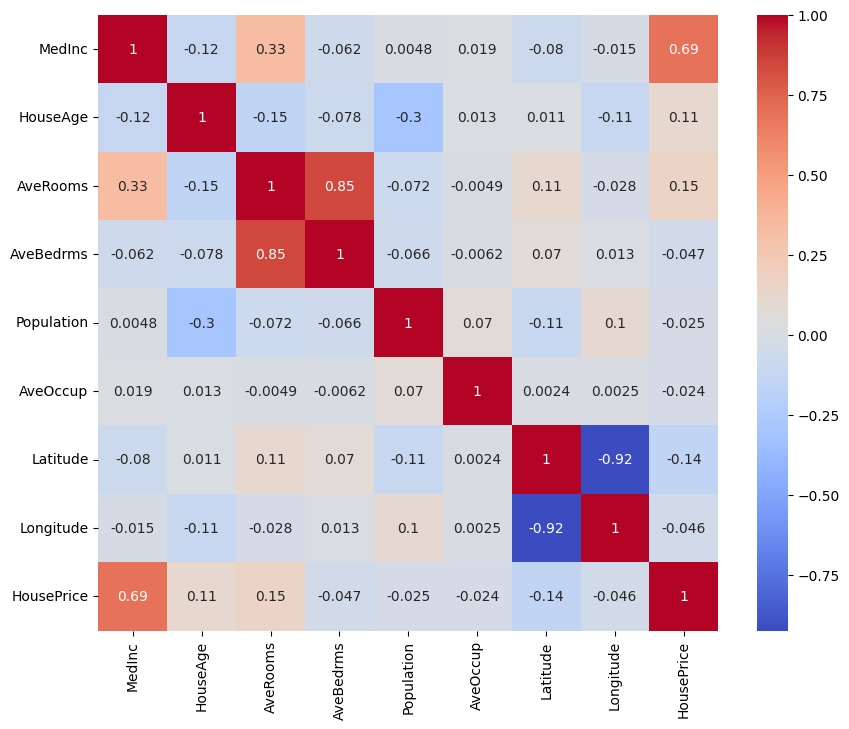

In [ ]:
corr=housing_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

corr['HousePrice'].abs().sort_values(ascending=False)


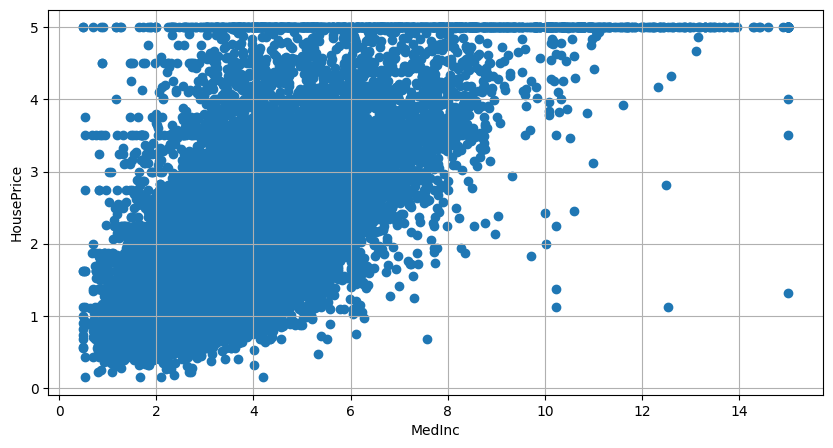

In [ ]:
medinc=housing_df['MedInc']
HousePrice=housing_df['HousePrice']
plt.figure(figsize=(10,5) )
plt.scatter(medinc,HousePrice)
plt.xlabel('MedInc')
plt.ylabel('HousePrice')
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
housing_df_vif=housing_df.drop('HousePrice',axis=1)
housing_df_vif=housing_df_vif.apply(pd.to_numeric,errors='coerce')

vf_data=pd.DataFrame()
vf_data['feature']=housing_df_vif.columns
vf_data['VIF']=[variance_inflation_factor(housing_df_vif.values,i) for i in range(housing_df_vif.shape[1])]
print(vf_data)


      feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


In [ ]:
# Assuming 'Latitude' and 'Longitude' were already removed
# If not and are present in the dataframe, uncomment the below line.
housing_df = housing_df.drop(['Latitude', 'Longitude'], axis=1)

cols_to_convert=['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup']
housing_df[cols_to_convert] = housing_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')
housing_df['HousePrice']=pd.to_numeric(housing_df['HousePrice'], errors='coerce')

X=sm.add_constant(housing_df.drop('HousePrice',axis=1))
y=housing_df['HousePrice']

model=sm.OLS(y,X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             HousePrice   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     4032.
Date:                Fri, 11 Apr 2025   Prob (F-statistic):               0.00
Time:                        09:00:05   Log-Likelihood:                -24235.
No. Observations:               20640   AIC:                         4.848e+04
Df Residuals:                   20633   BIC:                         4.854e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4391      0.028    -15.918      0.0

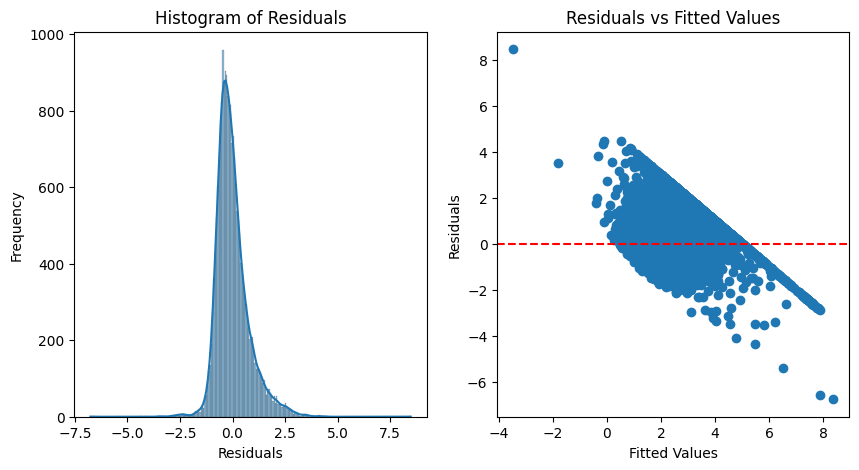

In [ ]:
residuals=model.resid
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(residuals,kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

plt.subplot(1,2,2)
plt.scatter(model.fittedvalues,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred=model.predict(X)
print("Mean square Error : ",mean_squared_error(y,y_pred))
print("R2 Square : ",r2_score(y,y_pred) )

Mean square Error :  0.6129156196698703
R2 Square :  0.5396977345638283


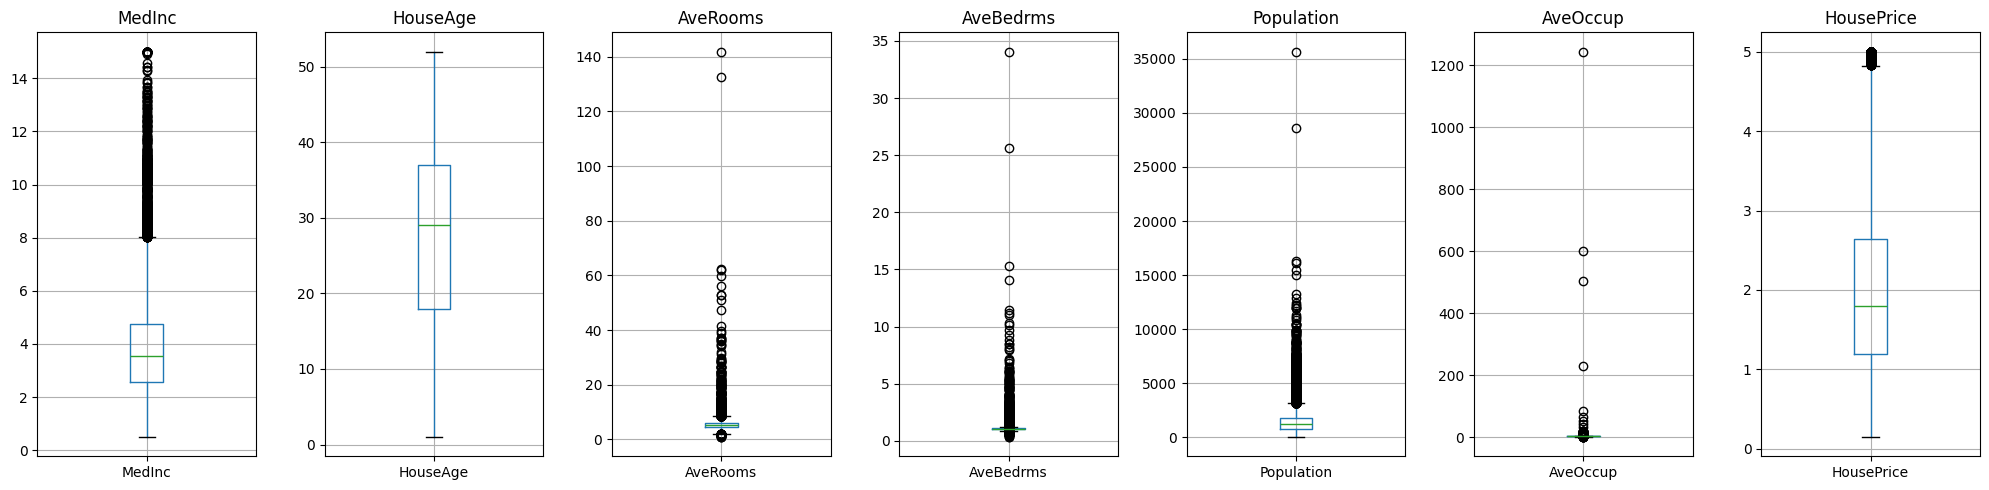

In [ ]:
import matplotlib.pyplot as plt

def plots_boxplot(df):

  fig,axes=plt.subplots(1,len(df.columns),figsize=(20,5))

  for i, column_name in enumerate(df.columns):
    df.boxplot(column=column_name,ax=axes[i])
    axes[i].set_title(column_name)

  plt.tight_layout()
  plt.show()

plots_boxplot(housing_df)

In [ ]:
def remove_outliers(df):
  df_no_outliers = df.copy()

  for column_name in df.columns:
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df_no_outliers[column_name] = df_no_outliers[column_name].apply(
        lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x
    )

  return df_no_outliers  # Return the modified DataFrame after processing all columns

# Call the function to remove outliers
new_housing_df = remove_outliers(housing_df)

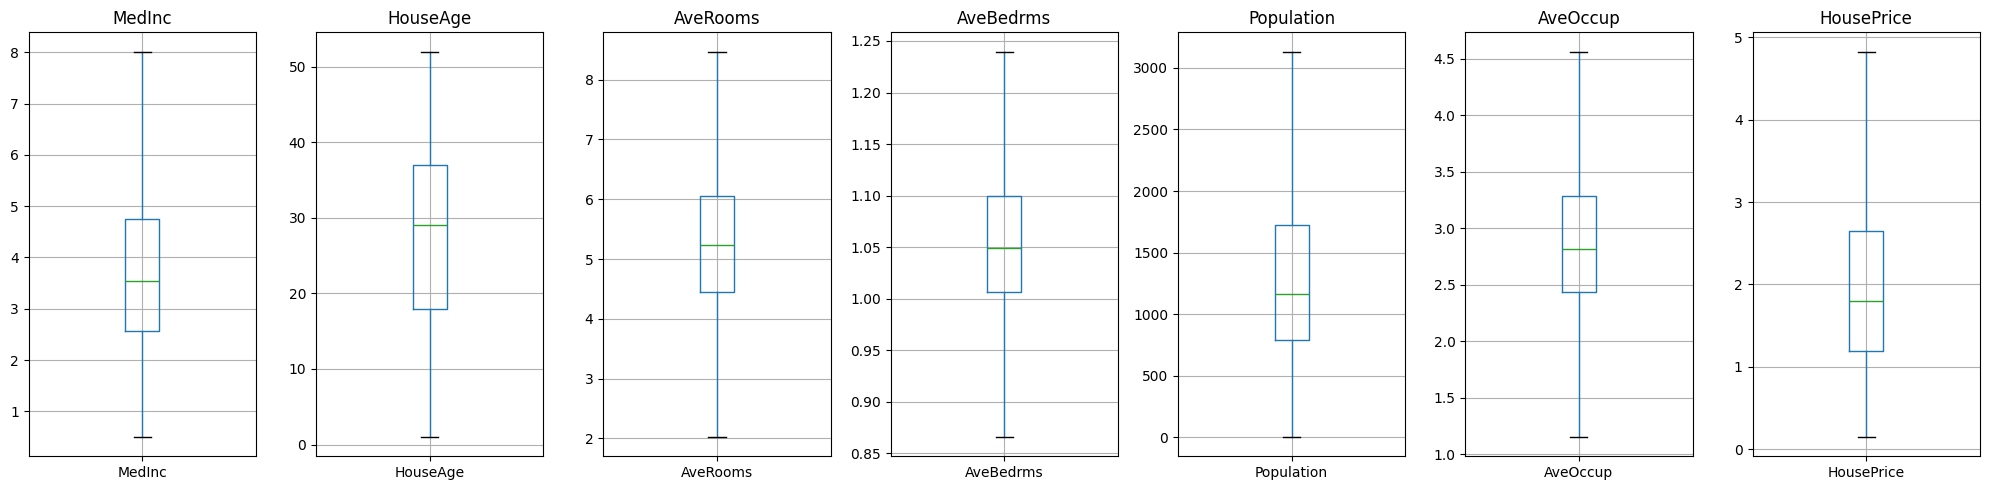

In [ ]:
plots_boxplot(df=new_housing_df)

In [ ]:
housing_df.shape

(20640, 7)

In [ ]:
new_housing_df.shape

(20640, 7)

In [ ]:
cols_to_convert=['MedInc','HouseAge','AveRooms','AveBedrms','Population','AveOccup']
new_housing_df[cols_to_convert] = new_housing_df[cols_to_convert].apply(pd.to_numeric, errors='coerce')
new_housing_df['HousePrice']=pd.to_numeric(new_housing_df['HousePrice'], errors='coerce')

X=sm.add_constant(new_housing_df.drop('HousePrice',axis=1))
y=new_housing_df['HousePrice']

model_1=sm.OLS(y,X).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:             HousePrice   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     5556.
Date:                Fri, 11 Apr 2025   Prob (F-statistic):               0.00
Time:                        09:15:24   Log-Likelihood:                -21926.
No. Observations:               20640   AIC:                         4.387e+04
Df Residuals:                   20633   BIC:                         4.392e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0257      0.082    -12.501      0.0

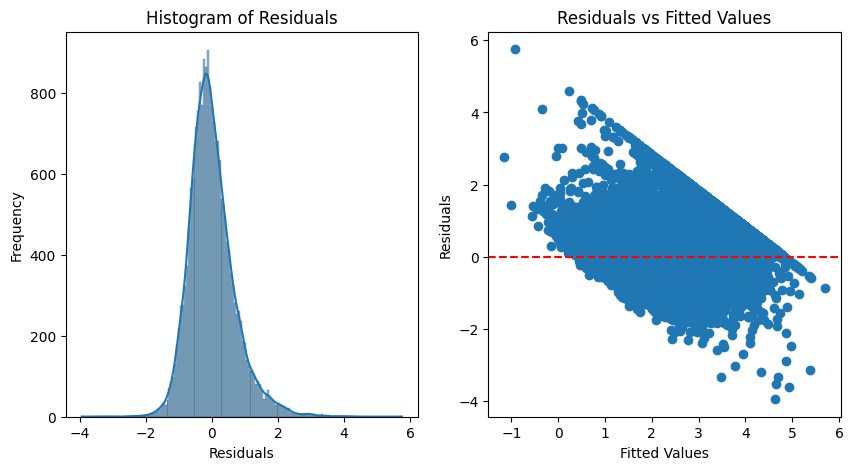

In [ ]:
residuals=model_1.resid
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(residuals,kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')

plt.subplot(1,2,2)
plt.scatter(model_1.fittedvalues,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score
y_pred=model_1.predict(X)
print("Mean square Error : ",mean_squared_error(y,y_pred))
print("R2 Square : ",r2_score(y,y_pred) )

Mean square Error :  0.49001892235770017
R2 Square :  0.617696810976802


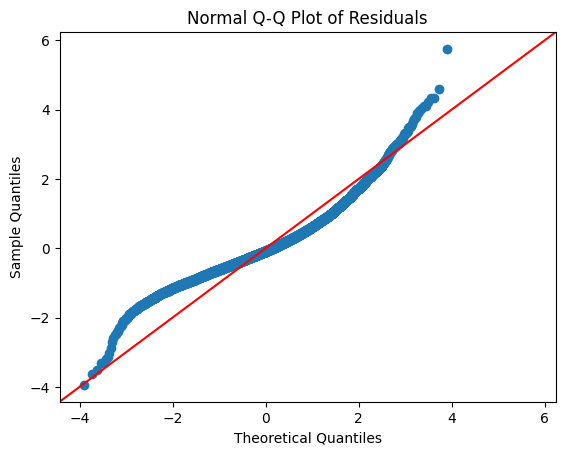

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Assuming 'residuals' contains the residuals from your model
# Replace 'residuals' with the actual variable name if different

sm.qqplot(residuals, line='45')  # '45' draws a 45-degree reference line
plt.title('Normal Q-Q Plot of Residuals')
plt.show()